# Retail Sales Performance Analysis

Setup

In [1]:
# ── Core ──────────────────────────────────────────────────────────────────────
import pandas as pd
import numpy as np

# ── Visualization ─────────────────────────────────────────────────────────────
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

# ── Utilities ─────────────────────────────────────────────────────────────────
import os
import warnings
from pathlib import Path

warnings.filterwarnings("ignore")

In [2]:
# ── Display Options ───────────────────────────────────────────────────────────
pd.set_option("display.max_columns",    50)
pd.set_option("display.max_rows",       100)
pd.set_option("display.float_format",   "{:.2f}".format)
pd.set_option("display.width",          1000)

# ── Plot Style ────────────────────────────────────────────────────────────────
sns.set_theme(style="whitegrid", palette="muted", font_scale=1.1)
plt.rcParams.update({
    "figure.figsize":   (12, 5),
    "figure.dpi":       120,
    "axes.spines.top":  False,
    "axes.spines.right":False,
})

In [5]:
df = pd.read_csv("Sample - Superstore.csv", encoding="ISO-8859-1")

In [ ]:
df.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,State,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,1,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.96,2,0.00,41.91
1,2,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.94,3,0.00,219.58
2,3,CA-2016-138688,6/12/2016,6/16/2016,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,California,90036,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.62,2,0.00,6.87
3,4,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.58,5,0.45,-383.03
4,5,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.37,2,0.20,2.52


In [9]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 9994 entries, 0 to 9993
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Row ID         9994 non-null   int64  
 1   Order ID       9994 non-null   str    
 2   Order Date     9994 non-null   str    
 3   Ship Date      9994 non-null   str    
 4   Ship Mode      9994 non-null   str    
 5   Customer ID    9994 non-null   str    
 6   Customer Name  9994 non-null   str    
 7   Segment        9994 non-null   str    
 8   Country        9994 non-null   str    
 9   City           9994 non-null   str    
 10  State          9994 non-null   str    
 11  Postal Code    9994 non-null   int64  
 12  Region         9994 non-null   str    
 13  Product ID     9994 non-null   str    
 14  Category       9994 non-null   str    
 15  Sub-Category   9994 non-null   str    
 16  Product Name   9994 non-null   str    
 17  Sales          9994 non-null   float64
 18  Quantity       9994

In [10]:
# ── Missing value report ──────────────────────────────────────────────────────
missing = (
    df.isnull()
      .sum()
      .rename("null_count")
      .to_frame()
      .assign(pct=lambda x: (x["null_count"] / len(df) * 100).round(2))
      .query("null_count > 0")
      .sort_values("pct", ascending=False)
)

print(f"Columns with nulls: {len(missing)}/{df.shape[1]}\n")
display(missing)

Columns with nulls: 0/21



,null_count,pct


In [11]:
# ── Duplicates ────────────────────────────────────────────────────────────────
n_dupes = df.duplicated().sum()
print(f"Duplicate rows: {n_dupes:,}  ({n_dupes / len(df) * 100:.2f}%)")

Duplicate rows: 0  (0.00%)


In [13]:
# ── Standardise column names ──────────────────────────────────────────────────
df.columns = (
    df.columns
      .str.strip()
      .str.lower()
      .str.replace(r"\s+",        "_", regex=True)
      .str.replace(r"[^\w]",      "_", regex=True)
      .str.replace(r"_+",         "_", regex=True)
      .str.strip("_")
)

print(df.columns.tolist())

['row_id', 'order_id', 'order_date', 'ship_date', 'ship_mode', 'customer_id', 'customer_name', 'segment', 'country', 'city', 'state', 'postal_code', 'region', 'product_id', 'category', 'sub_category', 'product_name', 'sales', 'quantity', 'discount', 'profit']


In [ ]:
# ── Convert date columns to datetime ───────────────────────────────────────────
date_cols = ["order_date", "ship_date"]

for col in date_cols:
    df[col] = pd.to_datetime(df[col], errors="coerce")

print(df[date_cols].dtypes)

order_date    datetime64[us]
ship_date     datetime64[us]
dtype: object


In [15]:
df["shipping_days"] = (
    pd.to_datetime(df["ship_date"], errors="coerce")
    - pd.to_datetime(df["order_date"], errors="coerce")
).dt.days

df[["order_date", "ship_date", "shipping_days"]].head()

,order_date,ship_date,shipping_days
0,2016-11-08,2016-11-11,3
1,2016-11-08,2016-11-11,3
2,2016-06-12,2016-06-16,4
3,2015-10-11,2015-10-18,7
4,2015-10-11,2015-10-18,7


In [16]:
df.head()

,row_id,order_id,order_date,ship_date,ship_mode,customer_id,customer_name,segment,country,city,state,postal_code,region,product_id,category,sub_category,product_name,sales,quantity,discount,profit,shipping_days
0,1,CA-2016-152156,2016-11-08,2016-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.96,2,0.00,41.91,3
1,2,CA-2016-152156,2016-11-08,2016-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.94,3,0.00,219.58,3
2,3,CA-2016-138688,2016-06-12,2016-06-16,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,California,90036,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.62,2,0.00,6.87,4
3,4,US-2015-108966,2015-10-11,2015-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.58,5,0.45,-383.03,7
4,5,US-2015-108966,2015-10-11,2015-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.37,2,0.20,2.52,7


# EDA

In [ ]:
# KPI summary: total revenue, total profit, average order value
total_revenue = df["sales"].sum()
total_profit = df["profit"].sum()

order_count = df["order_id"].nunique() if "order_id" in df.columns else len(df)
average_order_value = total_revenue / order_count if order_count else np.nan

kpi_summary = pd.DataFrame({
    "Metric": ["Total Revenue", "Total Profit", "Average Order Value"],
    "Value": [total_revenue, total_profit, average_order_value],
})

kpi_summary

,Metric,Value
0,Total Revenue,2297200.86
1,Total Profit,286397.02
2,Average Order Value,458.61


In [18]:
# Which category generates the most sales and the most profit?
category_summary = (
    df.groupby("category", as_index=False)
      .agg(total_sales=("sales", "sum"), total_profit=("profit", "sum"))
      .sort_values("total_sales", ascending=False)
      .reset_index(drop=True)
)

top_sales_category = category_summary.loc[category_summary["total_sales"].idxmax(), "category"]
top_profit_category = category_summary.loc[category_summary["total_profit"].idxmax(), "category"]

print(f"Top category by Sales: {top_sales_category}")
print(f"Top category by Profit: {top_profit_category}")

category_summary

Top category by Sales: Technology
Top category by Profit: Technology


,category,total_sales,total_profit
0,Technology,836154.03,145454.95
1,Furniture,741999.80,18451.27
2,Office Supplies,719047.03,122490.80


In [19]:
# Which sub-category is most profitable and which is losing money?
subcat_profit = (
    df.groupby("sub_category", as_index=False)
      .agg(total_profit=("profit", "sum"))
      .sort_values("total_profit", ascending=False)
      .reset_index(drop=True)
)

most_profitable_subcat = subcat_profit.loc[subcat_profit["total_profit"].idxmax(), "sub_category"]
most_loss_subcat = subcat_profit.loc[subcat_profit["total_profit"].idxmin(), "sub_category"]

print(f"Most profitable sub-category: {most_profitable_subcat}")
print(f"Sub-category losing the most money: {most_loss_subcat}")

subcat_profit

Most profitable sub-category: Copiers
Sub-category losing the most money: Tables


,sub_category,total_profit
0,Copiers,55617.82
1,Phones,44515.73
2,Accessories,41936.64
3,Paper,34053.57
4,Binders,30221.76
5,Chairs,26590.17
6,Storage,21278.83
7,Appliances,18138.01
8,Furnishings,13059.14
9,Envelopes,6964.18


In [20]:
# Which region performs best?
region_summary = (
    df.groupby("region", as_index=False)
      .agg(total_sales=("sales", "sum"), total_profit=("profit", "sum"))
      .sort_values("total_sales", ascending=False)
      .reset_index(drop=True)
)

best_region_by_sales = region_summary.loc[region_summary["total_sales"].idxmax(), "region"]
best_region_by_profit = region_summary.loc[region_summary["total_profit"].idxmax(), "region"]

print(f"Best region by Sales: {best_region_by_sales}")
print(f"Best region by Profit: {best_region_by_profit}")

region_summary

Best region by Sales: West
Best region by Profit: West


,region,total_sales,total_profit
0,West,725457.82,108418.45
1,East,678781.24,91522.78
2,Central,501239.89,39706.36
3,South,391721.91,46749.43


In [21]:
# Which customer segment brings the highest revenue?
segment_revenue = (
    df.groupby("segment", as_index=False)
      .agg(total_revenue=("sales", "sum"))
      .sort_values("total_revenue", ascending=False)
      .reset_index(drop=True)
)

top_segment = segment_revenue.loc[segment_revenue["total_revenue"].idxmax(), "segment"]
print(f"Customer segment with highest revenue: {top_segment}")

segment_revenue

Customer segment with highest revenue: Consumer


,segment,total_revenue
0,Consumer,1161401.34
1,Corporate,706146.37
2,Home Office,429653.15


In [23]:
df.head()

,row_id,order_id,order_date,ship_date,ship_mode,customer_id,customer_name,segment,country,city,state,postal_code,region,product_id,category,sub_category,product_name,sales,quantity,discount,profit,shipping_days
0,1,CA-2016-152156,2016-11-08,2016-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.96,2,0.00,41.91,3
1,2,CA-2016-152156,2016-11-08,2016-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.94,3,0.00,219.58,3
2,3,CA-2016-138688,2016-06-12,2016-06-16,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,California,90036,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.62,2,0.00,6.87,4
3,4,US-2015-108966,2015-10-11,2015-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.58,5,0.45,-383.03,7
4,5,US-2015-108966,2015-10-11,2015-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.37,2,0.20,2.52,7


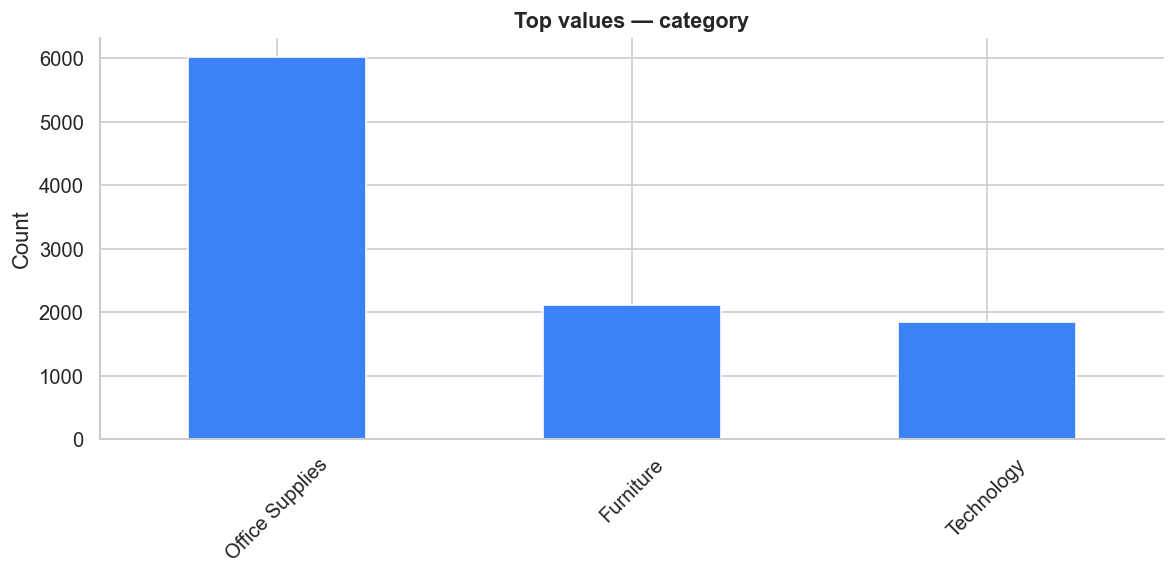

In [ ]:
# ── Bar chart — categorical counts ───────────────────────────────────────────

col = "category"
counts = df[col].value_counts().head(15)

fig, ax = plt.subplots(figsize=(10, 5))
counts.plot.bar(ax=ax, color="#3B82F6", edgecolor="white")
ax.set_title(f"Top values — {col}", fontsize=13, fontweight="bold")
ax.set_xlabel("")
ax.set_ylabel("Count")
ax.tick_params(axis="x", rotation=45)
plt.tight_layout()
plt.show()

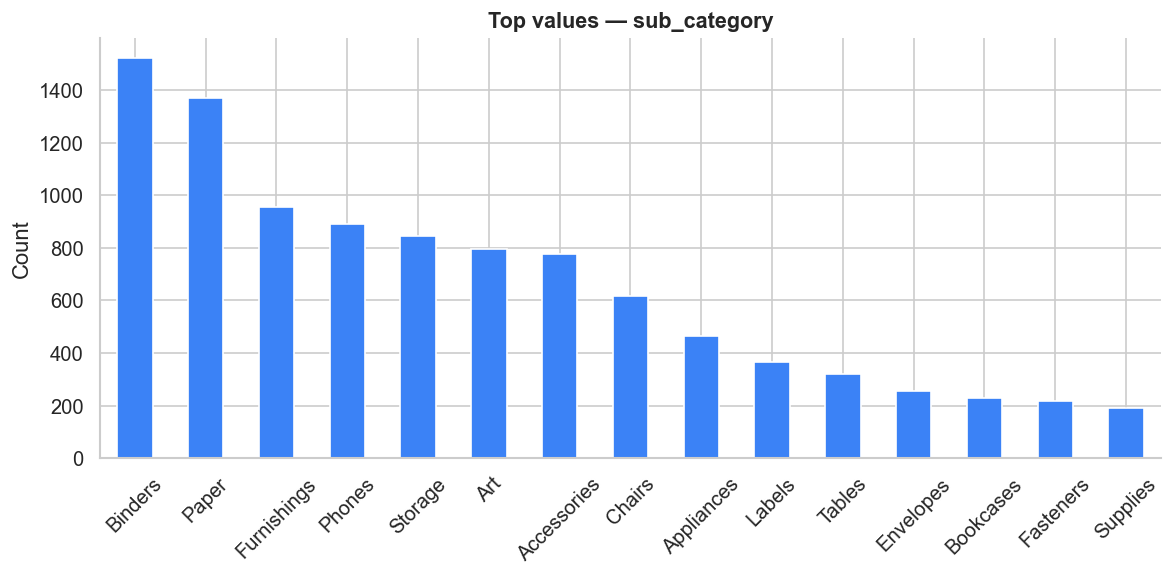

In [27]:
# ── Bar chart — Sub-categorical counts ───────────────────────────────────────────

col = "sub_category"
counts = df[col].value_counts().head(15)

fig, ax = plt.subplots(figsize=(10, 5))
counts.plot.bar(ax=ax, color="#3B82F6", edgecolor="white")
ax.set_title(f"Top values — {col}", fontsize=13, fontweight="bold")
ax.set_xlabel("")
ax.set_ylabel("Count")
ax.tick_params(axis="x", rotation=45)
plt.tight_layout()
plt.show()

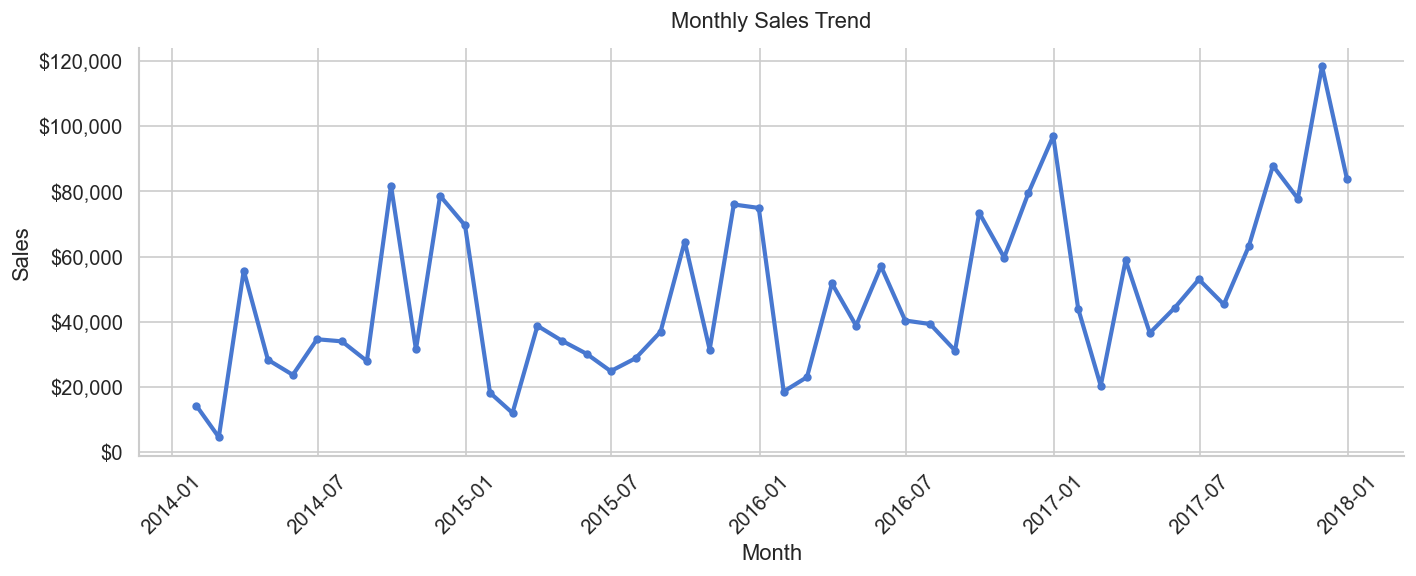

In [30]:
# Line chart: Monthly Sales Trend over time
df["order_date"] = pd.to_datetime(df["order_date"], errors="coerce")

monthly_sales = (
    df.dropna(subset=["order_date"])
      .set_index("order_date")
      .resample("ME")["sales"]
      .sum()
      .reset_index()
      .rename(columns={"order_date": "month", "sales": "total_sales"})
)

fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(monthly_sales["month"], monthly_sales["total_sales"], linewidth=2.5, marker="o", markersize=4)
ax.set_title("Monthly Sales Trend", pad=12)
ax.set_xlabel("Month")
ax.set_ylabel("Sales")
ax.yaxis.set_major_formatter(mticker.StrMethodFormatter("${x:,.0f}"))
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

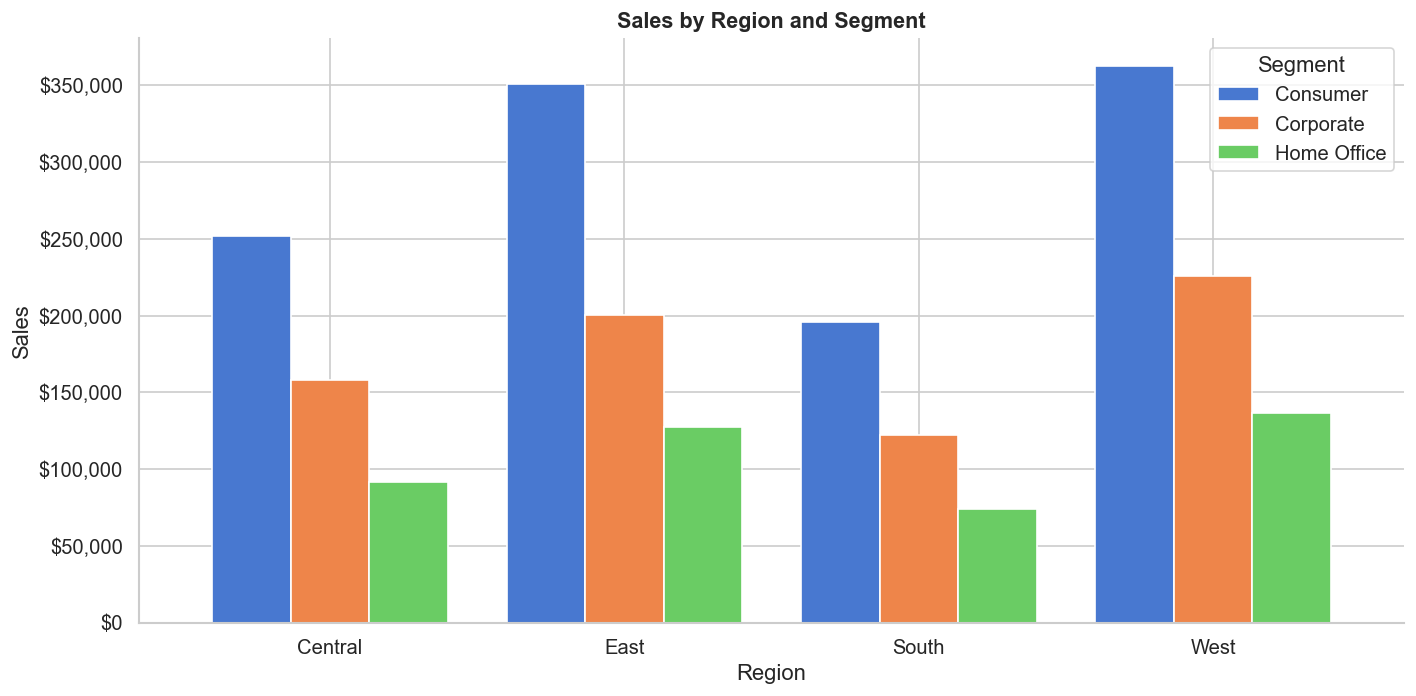

In [39]:
# Bar chart: Sales by Region and Segment
sales_region_segment = (
    df.pivot_table(
        index="region",
        columns="segment",
        values="sales",
        aggfunc="sum",
        fill_value=0,
    )
    .sort_index()
)

fig, ax = plt.subplots(figsize=(12, 6))
sales_region_segment.plot(kind="bar", ax=ax, width=0.8)
ax.set_title("Sales by Region and Segment", fontsize=13, fontweight="bold")
ax.set_xlabel("Region")
ax.set_ylabel("Sales")
ax.yaxis.set_major_formatter(mticker.StrMethodFormatter("${x:,.0f}"))
ax.tick_params(axis="x", rotation=0)
ax.legend(title="Segment")

plt.tight_layout()
plt.show()

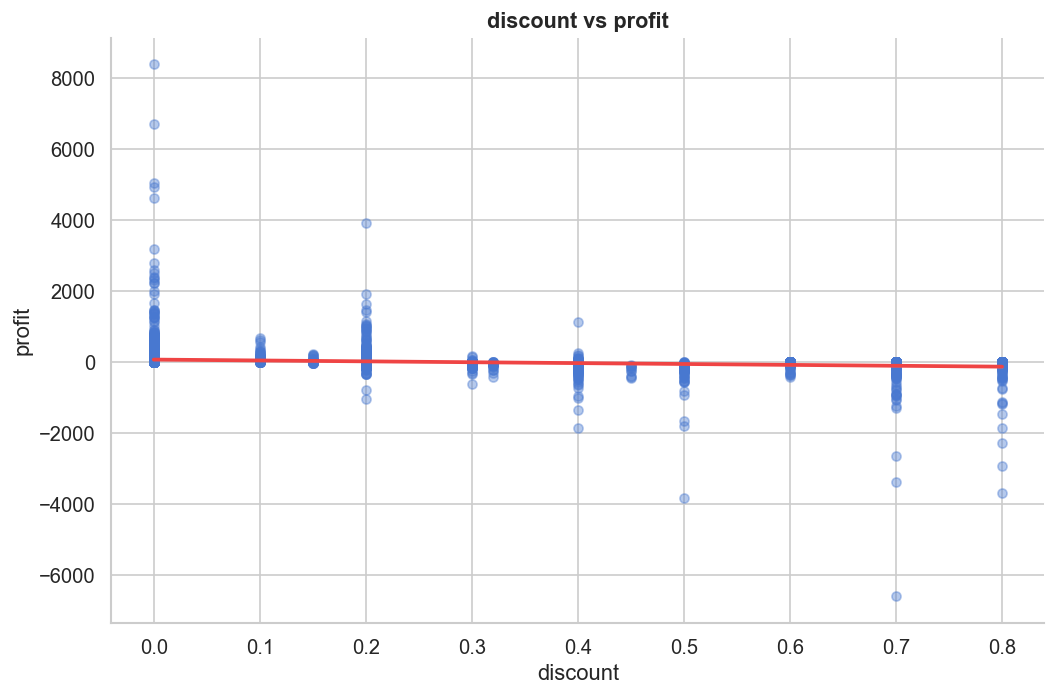

In [44]:
# ── Scatter plot with regression line ────────────────────────────────────────
# ↓ Replace with your columns

x_col = "discount"
y_col = "profit"

fig, ax = plt.subplots(figsize=(9, 6))
sns.regplot(
    data=df,
    x=x_col,
    y=y_col,
    ax=ax,
    scatter_kws={"alpha": 0.4, "s": 30},
    line_kws={"color": "#EF4444"},
)
ax.set_title(f"{x_col} vs {y_col}", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

## Executive Summary
- **Revenue is primarily driven by the Technology category**, with Consumer as the strongest customer segment and the West region contributing the highest sales overall.
- **Profitability is being hurt most by specific sub-categories**, especially Tables (largest loss), with additional pressure from Bookcases and Supplies.
- **Higher discount levels are associated with weaker profit outcomes**, as seen in the discount vs profit trend where profitability declines as discount increases.
- A notable finding is that **the same areas driving revenue are not always evenly profitable** at a granular product level, so category-level growth can hide sub-category losses.
- **Action for the Sales Director:** implement discount guardrails (especially on Tables and other loss-making sub-categories) while prioritizing high-performing combinations (Technology + Consumer + West) to grow revenue without eroding margin.